# Zero-noise extrapolation with probabilistic error amplification
Zero-noise extrapolation (ZNE) is a technique for mitigating quantum noise in observable expectation value calculations. It works by executing a quantum circuit at increasing noise scales, taking expectation values with respect to those noise scales, and extrapolating to estimate a zero-noise expectation value. Both the noise amplification and extrapolation stages can be implemented in different ways. In this guide we amplify the noise with probabilistic error amplification (PEA), as suggested in ["Evidence for the utility of quantum computing before fault tolerance"](https://www.nature.com/articles/s41586-023-06096-3). To amplify with PEA, we must first model the noise affecting the circuit's entangling gates.  One can also implement amplification with digital gate folding, which needs no noise model and is covered in the [gate folding guide](gate_folding_with_custom_extrapolation.ipynb). We learn the noise with [``qiskit-noise-learning``](https://github.com/Qiskit/qiskit-noise-learning) and extrapolate with the built-in exponential fitting strategy.

Keep in mind, while ZNE can be effective at mitigating quantum noise for a lower sampling cost than other methods, it comes with no bounds on the bias.

<img src="../images/zne_extrapolation.png" width="450"/>

The workflow will be as follows:
1. Specify a circuit and observable
2. Compute exact expectation values using Qiskit's statevector simulator
3. Compute noisy, unmitigated expectation values
4. Learn the noise of the entangling layers with qiskit-noise-learning
5. Prepare a ZNE program with probabilistic error amplification and sample circuits of varying noise scales
6. Extrapolate to the zero-noise limit
7. Compare the mitigated expectation values

### Specify a circuit and observable

In this guide we will calculate the site-averaged magnetization $\langle Z \rangle_{\text{avg}} = \frac{1}{N} \sum_{i=1}^{N} \langle Z_i \rangle$ of a Trotterized transverse-field Ising model (TFIM) on ``8`` qubits in a ring topology. We will sweep several values of the strength of the transverse field and plot the magnetization as a function of the field strength. In a ring topology on an even number of qubits, the two-qubit gate layers can be split into 2 unique layers, as the red and green colors show in the coupling map below. Designing circuits to have a minimal set of unique entangling layers is important if one wants to learn a noise model, as the unique layers must be learned independently. If one has too many unique layers in their circuit, noise learning can become infeasible due to the sampling cost of learning many layers.

Edges of the same color may execute their gates simultaneously.


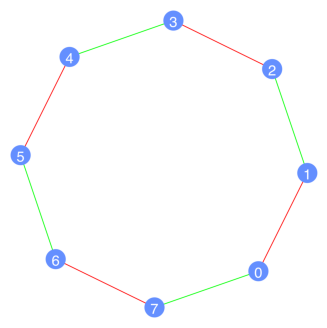

Visualization of 1 Trotter step


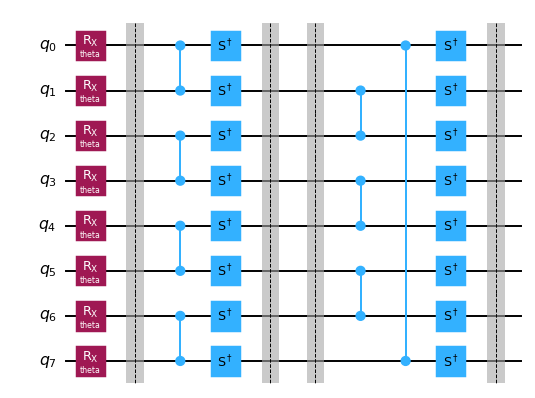

In [1]:
import warnings

import IPython.display
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import plot_coupling_map

warnings.filterwarnings("ignore")


def trotter_circuit(num_qubits, theta, layers, num_steps):
    """Trotterized transverse-field Ising evolution: RX on every site, then a CZ layer per coupling layer."""
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(theta, range(num_qubits))
        for layer in layers:
            circuit.barrier()
            for edge in layer:
                circuit.cz(*edge)
                circuit.sdg(edge)
            circuit.barrier()
    return circuit


num_qubits = 8
trotter_steps = 15
ring_coupling = [(i, (i + 1) % num_qubits) for i in range(num_qubits)]
layers = [ring_coupling[0::2], ring_coupling[1::2]]  # two disjoint layers of CZ gates
theta = Parameter("theta")
circuit = trotter_circuit(num_qubits, theta, layers, trotter_steps)

# Parameter values: theta in [0, 0.25 pi] - values for the transverse-field sweep
data_points = 6
parameter_values = np.linspace(0, 0.25 * np.pi, data_points).reshape((data_points, 1))

# Define observables - Z on each site
observables = [SparsePauliOp("I" * (num_qubits - q - 1) + "Z" + "I" * q) for q in range(num_qubits)]

print("Edges of the same color may execute their gates simultaneously.")
IPython.display.display(
    plot_coupling_map(
        num_qubits=num_qubits,
        qubit_coordinates=None,
        coupling_map=ring_coupling,
        figsize=(4, 4),
        qubit_size=150,
        line_width=5,
        line_color=["red" if edge in layers[0] else "green" for edge in ring_coupling],
        font_size=90,
    )
)
print("Visualization of 1 Trotter step")
trotter_circuit(num_qubits, theta, layers, 1).draw("mpl", scale=0.7)

### Compute exact expectation values using Qiskit's statevector simulator

We use Qiskit's ``Statevector`` class to compute the exact expectation value of $Z_i$ on each site for every value of $\theta$.

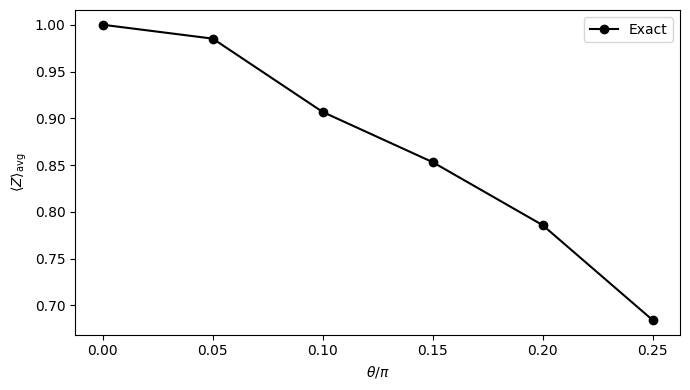

In [2]:
from qiskit.quantum_info import Statevector

exact_evs = np.array(
    [
        [
            Statevector(circuit.assign_parameters([value])).expectation_value(obs).real
            for value in parameter_values.ravel()
        ]
        for obs in observables
    ]
)  # shape (observables, parameter values)

import matplotlib.pyplot as plt

x_vals = parameter_values.ravel() / np.pi
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "ko-", label="Exact")
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\langle Z \rangle_{\text{avg}}$")
ax.legend()
plt.tight_layout()
plt.show()

### Compute noisy, unmitigated expectation values

A ``QuantumProgram`` contains a quantum circuit and a samplex in a format suitable for the [Executor primitive](https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-executor). `MitigationTask.prepare` builds a ``QuantumProgram`` from the circuit, the observables and the parameter values, and boxes the circuit with the given boxing options. We set the ``measure_annotations`` boxing option to ``"change_basis"`` which rotates the measurements into the required bases, and we add ``add_tags: "unique_box"`` so the simulator can map a noise model onto the boxes of the circuit. The program is Pauli twirled by default, which on hardware turns coherent noise into the Pauli noise that the mitigation methods assume. `num_randomizations` sets how many twirled instances of each circuit are sampled and `shots_per_randomization` sets how many shots each instance receives, so their product is the shot budget per circuit.

A user with QPU access would execute the program with an `Executor` built from a backend of the `QiskitRuntimeService`. Here we pass an `AerSimulator` to the `Executor`, which runs the program locally, and use its `layer_noise_model` simulator option to inject a random Pauli-Lindblad noise model on every layer of entangling gates, generated with `random_pauli_lindblad_noise` from `qiskit-mitigation` with an error per layered gate (EPLG) of ``0.003``, typical of current Heron QPUs.

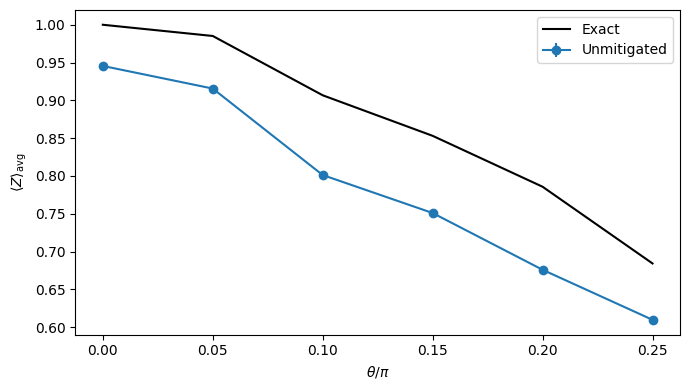

In [3]:
from qiskit.circuit import CircuitInstruction
from qiskit.quantum_info import PauliLindbladMap, pauli_basis
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Executor
from qiskit_mitigation import MitigationTask, find_combined_unique_layers


def generate_random_pauli_lindblad_noise(
    layers,
    num_qubits: int,
    eplg: float = 3e-3,
    seed: int | None = None,
) -> list[tuple[CircuitInstruction, PauliLindbladMap]]:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    layer_noise_model = []
    for layer in layers:
        layer_instructions = layer.operation.params[0]
        contain_measurement = any(inst.name.startswith("measure") for inst in layer_instructions)
        if contain_measurement:  # do not add measurement noise
            layer_noise = PauliLindbladMap.identity(num_qubits)
        else:
            edges = [
                (inst.qubits[0]._index, inst.qubits[1]._index) for inst in layer_instructions
            ]  # extract the edges of the layer

            basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
            rng = np.random.default_rng(seed=seed)
            num_generators = len(basis_paulis)
            rates = rng.random(len(basis_paulis)) * eplg / num_generators

            layer_noise = PauliLindbladMap.from_sparse_list(
                [
                    (pauli.to_label(), edge, rate)
                    for pauli, rate in zip(basis_paulis, rates, strict=True)
                    for edge in edges
                ],
                num_qubits=num_qubits,
            )
        layer_noise_model.append((layer, layer_noise))
    return layer_noise_model


num_randomizations = 50
shots_per_randomization = 64

boxing_options = {"measure_annotations": "change_basis", "add_tags": "unique_box"}

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([circuit], custom_boxing_options=boxing_options)
layer_noise_model = generate_random_pauli_lindblad_noise(box_layers, num_qubits, seed=42)

# a local noisy simulator in place of a QPU backend
noisy_executor = Executor(
    AerSimulator(), options={"simulator": {"layer_noise_model": layer_noise_model}}
)

task = MitigationTask()
program = task.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)
program._semantic_role = "simulation"  # flag the program for the simulator
unmitigated_res = task.postprocess(noisy_executor.run(program).result())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "k-", label="Exact")
ax.errorbar(
    x_vals,
    np.mean(unmitigated_res.data.evs, axis=0),
    np.mean(unmitigated_res.data.stds, axis=0),
    fmt="o-",
    label="Unmitigated",
)
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\langle Z \rangle_{\text{avg}}$")
ax.legend()
plt.tight_layout()
plt.show()

### Learn the noise of the entangling layers with qiskit-noise-learning

PEA starts by learning the twirled noise model of each layer of entangling gates in the circuit. We assume a Markovian noise model, therefore only the noise model of each unique layer of entangling gates should be learned, as the depth of the circuit is assumed to not affect the noise channel of a given entangling layer. The more accurate the learned noise model is, the more accurate the amplification will be.

We use `qiskit-noise-learning` for learning the noise. The learner repeats each layer `fragment_depths` times in its learning circuits, twirls each circuit `num_randomizations` times, and fits the decay of the measured fidelities to a Pauli-Lindblad model. Below we draw the learned noise model, with the two layers merged into one map. Each qubit is a pie of its weight-1 X, Y and Z rates summed over the two layers, and each edge shows the learned weight-2 rates; a rate of ``3e-4`` means that error occurs on roughly 3 of every 10,000 uses of the layer.

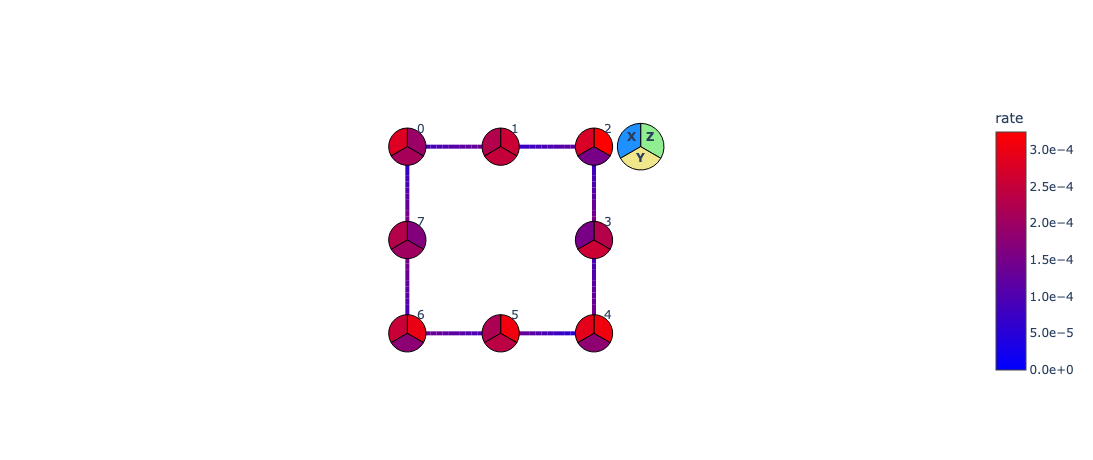

In [4]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliList
from qiskit_ibm_runtime.results import LayerError, PauliLindbladError
from qiskit_ibm_runtime.visualization.embeddings import Embedding
from qiskit_mitigation import PEA
from qiskit_noise_learning.aer_executor import AerExecutor
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner
from samplomatic import InjectNoise, Tag
from samplomatic.utils import get_annotation

backend = GenericBackendV2(
    num_qubits=num_qubits, basis_gates=["id", "rz", "sx", "x", "cz"], coupling_map=ring_coupling
)

task_pea = PEA()
# learn only the layers PEA will inject noise into, i.e. not the measurement layer
pea_layers = [
    layer
    for layer in task_pea.find_unique_layers(circuit, boxing_options)
    if get_annotation(layer.operation, InjectNoise)
]

learning_options = LearningOptions(
    fragment_depths=[2, 4, 8, 16], num_randomizations=50, shots_per_randomizations=64
)
# qiskit-noise-learning is not compatible with the Executor in local mode,
# and requires the simulator present in the package for running simulation
noise_dict = {
    get_annotation(layer.operation, Tag).ref: noise_layer
    for layer, noise_layer in layer_noise_model
}
noise_learner_simulator = AerExecutor(qasm_simulator=AerSimulator(), noise_dict=noise_dict)
learner = NoiseLearner(backend, options=learning_options, executor=noise_learner_simulator)
learned_noise = learner.run(pea_layers).result().to_dict()  # keyed by InjectNoise reference

# Draw the learned model on the ring, laid out as a square with the qubits in ring order.
# Composing the two layers' maps sums their rates, giving one map over all the ring's edges.
embedding = Embedding(
    [(0, 0), (0, 2), (0, 4), (2, 4), (4, 4), (4, 2), (4, 0), (2, 0)], ring_coupling
)
first, second = learned_noise.values()
learned_model = first.compose(second).simplify()
error = PauliLindbladError(
    PauliList(learned_model.get_qubit_sparse_pauli_list_copy().to_pauli_list()), learned_model.rates
)
fig = LayerError(circuit, list(range(num_qubits)), error).draw_map(
    embedding, radius=0.4, height=460, width=620
)
fig.update_traces(
    marker={
        "cmin": 0,
        "cmax": max(learned_model.rates),
        "colorbar": {"tickformat": ".1e", "title": "rate"},
    },
    selector={"mode": "markers"},
)
fig.show()

### Prepare a ZNE program with probabilistic error amplification and sample circuits of varying noise scales

Here we prepare a ZNE program containing circuits of increasing noise scales. With PEA, each noise factor represents the multiple of the learned noise the circuit experiences: a noise factor of ``2.0`` injects one additional copy of each layer's learned noise channel after that layer, on top of the noise the layer already has. Because PEA scales the learned noise rates directly rather than repeating gates, any noise factor is possible, including non-integer ones, and the circuit itself is not modified: the program items share one template circuit and differ only in the noise injected by the samplex. The injected noise is sampled once per randomization, so the statistical error of PEA is controlled by the number of randomizations rather than the shots per randomization; we therefore use many randomizations with few shots each, keeping the total number of shots the same as for the unmitigated program. It is important to not use too few randomizations, as otherwise you might encounter sampling bias in the noise injection.

The total sampling overhead scales linearly with the number of noise factors. 

In [5]:
noise_factors = [1, 2, 3]
program_pea = task_pea.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=200,
    shots_per_randomization=16,
    custom_boxing_options=boxing_options,
    noise_maps=learned_noise,
    noise_factors=noise_factors,
)

Finally, we run the program on the noisy simulator. Its results feed the extrapolation in the next step.

In [6]:
program_pea._semantic_role = "simulation"  # flag the program for the simulator
job_pea_results = noisy_executor.run(program_pea).result()

### Extrapolate to the zero-noise limit

Now that we have data for each noise scale, we can fit a function to the data and extrapolate back to the zero-noise value to estimate an expectation value of the noise-free observable. Under Pauli noise an observable decays exponentially with the noise factor, so we choose the exponential extrapolator as our first choice, and fall back to the linear one if the exponential fit fails. To visualize the extrapolation, we plot the site-averaged magnetization calculated at each noise factor, the exponential fit, and the site average of the extrapolated expectation values at the zero-noise point. We see the fit slightly undershoots for this particular observable.

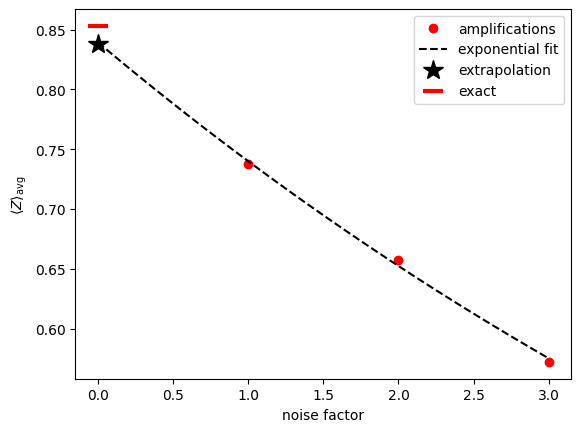

In [7]:
from scipy.optimize import curve_fit

pea_mitigated_res = task_pea.postprocess(job_pea_results, extrapolator=["exponential", "linear"])

# The result holds the expectation value at each noise factor and the extrapolated value for
# every observable; we average them over the sites and fit the same model to draw the curve.
angle = 3  # theta = 0.15 pi, the angle with the largest unmitigated error
amplifications = pea_mitigated_res.data.evs_noise_factors[:, angle, :].mean(axis=0)
x_fit = np.linspace(0, max(noise_factors), 51)
params, _ = curve_fit(
    lambda x, a, b: a * np.exp(b * x), noise_factors, amplifications, p0=[1.0, -0.1]
)

plt.plot(noise_factors, amplifications, "o", color="red", label="amplifications")
plt.plot(x_fit, params[0] * np.exp(params[1] * x_fit), "--", color="black", label="exponential fit")
plt.plot(
    [0],
    pea_mitigated_res.data.evs[:, angle].mean(),
    "*",
    color="black",
    markersize=15,
    label="extrapolation",
)
plt.plot(
    [0],
    exact_evs[:, angle].mean(),
    "_",
    color="red",
    markersize=15,
    markeredgewidth=3,
    label="exact",
)
plt.xlabel("noise factor")
plt.ylabel(r"$\langle Z \rangle_{\text{avg}}$")
plt.legend()
plt.show()

### Compare the mitigated expectation values

Here we plot the site-averaged magnetization of each method across the sweep of Ising rotation angles. PEA recovers the exact magnetization within its error bars, while the unmitigated result is biased well below it.

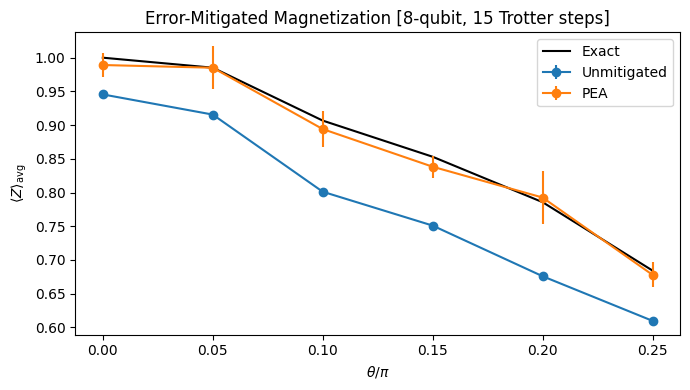

In [8]:
results = {
    "Unmitigated": unmitigated_res,
    "PEA": pea_mitigated_res,
}

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, exact_evs.mean(axis=0), "k-", label="Exact")
for label, res in results.items():
    ax.errorbar(
        x_vals,
        np.mean(res.data.evs, axis=0),
        np.mean(res.data.stds, axis=0),
        fmt="o-",
        label=label,
    )
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\langle Z \rangle_{\text{avg}}$")
ax.legend()
ax.set_title(f"Error-Mitigated Magnetization [{num_qubits}-qubit, {trotter_steps} Trotter steps]")
plt.tight_layout()
plt.show()